In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set(style="whitegrid")

print("Libraries loaded")


Libraries loaded


# data exploration  - Welltory COVID-19 Wearables Dataset
Author: Jaideep Aher  

# introduction & Context
- this dataset was collected sfor researchers to study patterns which ought to predict symptoms of Covid-19
- this data comes from the Welltory covid-19 study
- data contains data points such as - HRV, heart rate, sleep, surveys, etc.






In [2]:
participants = pd.read_csv("../data/participants.csv")

#basic info
participants.info()
participants.isna().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 185 entries, 0 to 184
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   user_code       185 non-null    object 
 1   gender          185 non-null    object 
 2   age_range       185 non-null    object 
 3   city            173 non-null    object 
 4   country         179 non-null    object 
 5   height          183 non-null    float64
 6   weight          185 non-null    float64
 7   symptoms_onset  147 non-null    object 
dtypes: float64(2), object(6)
memory usage: 11.7+ KB


user_code          0
gender             0
age_range          0
city              12
country            6
height             2
weight             0
symptoms_onset    38
dtype: int64

In [3]:

participants.describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
user_code,185,185,007b8190cf,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,185,2,f,118,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age_range,185,6,35-44,56,NaN,NaN,NaN,NaN,NaN,NaN,NaN
city,173,116,Moscow,34,NaN,NaN,NaN,NaN,NaN,NaN,NaN
country,179,25,Russia,66,NaN,NaN,NaN,NaN,NaN,NaN,NaN
height,183.0,NaN,NaN,NaN,169.976393,12.400103,132.08,163.5,168.0,174.5,250.0
weight,185.0,NaN,NaN,NaN,77.927757,19.552541,43.5,63.5,74.344,90.537,154.221
symptoms_onset,147,74,5/6/2020,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#initial Insights
- The dataset has 185 participants with 8 features.  
- `gender`, `age_range`, `city`, `country`, and `symptoms_onset` are categorical.  
- `height` and `weight` are numeric.  
- there are some missing values:
  - 12 in `city`
  - 6 in `country`
  - 2 in `height`
  - 38 in `symptoms_onset`  

observations:
- gender distribution is skewed towards female participants.  
- most participants fall in the 35–44 age group.  
- average height is 170 cm and average weight is 78 kg.  
- maximum recorded height (250 cm) is unrealistic - flagged as outlier.  
- symptom onset dates vary, but many are missing. 


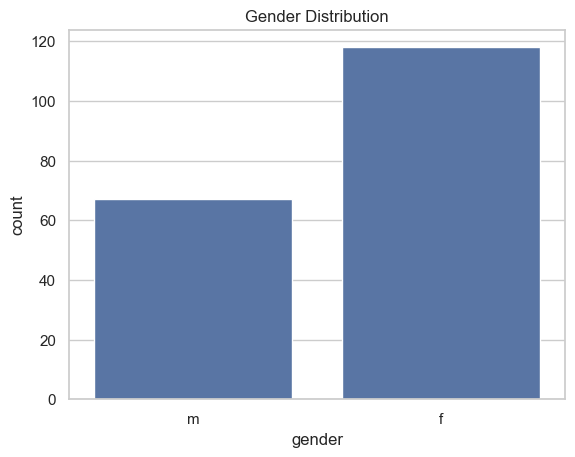

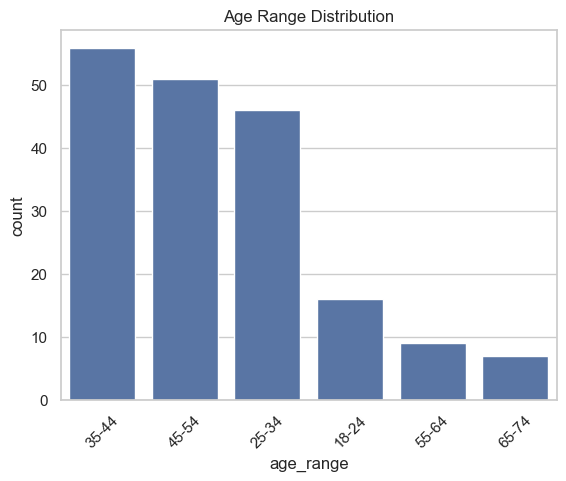

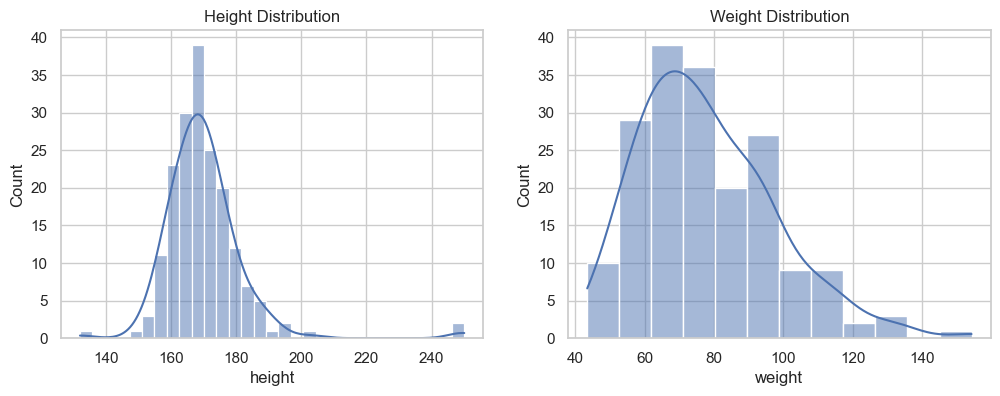

In [5]:
#exploration
sns.countplot(data=participants, x="gender")
plt.title("Gender Distribution")
plt.show()

sns.countplot(data=participants, x="age_range", order=participants['age_range'].value_counts().index)
plt.title("Age Range Distribution")
plt.xticks(rotation=45)
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12,4))
sns.histplot(participants['height'], kde=True, ax=axes[0])
axes[0].set_title("Height Distribution")
sns.histplot(participants['weight'], kde=True, ax=axes[1])
axes[1].set_title("Weight Distribution")
plt.show()



#data Cleaning
we will handle some missing values as follows
- City - filled with `"Unknown"` because it is categorical and dropping rows would lose participants 
- Country - filled with `"Unknown"` for the same reason. 
- height - only 2 missing values, filled with median height (more robust than mean)  

this ensures data completeness while avoiding unrealistic values


In [6]:
participants['city'] = participants['city'].fillna("Unknown")
participants['country'] = participants['country'].fillna("Unknown")
participants['height'] = participants['height'].fillna(participants['height'].median())

participants.isna().sum()

user_code          0
gender             0
age_range          0
city               0
country            0
height             0
weight             0
symptoms_onset    38
dtype: int64

In [7]:
# new feauture of BMI
participants['height_m'] = participants['height'] / 100
participants['BMI'] = participants['weight'] / (participants['height_m']**2)

participants[['user_code','height','weight','BMI']].head()


,user_code,height,weight,BMI
0,007b8190cf,170.18,96.162,33.203698
1,013f6d3e5b,174.00,77.300,25.531774
2,01bad5a519,178.00,92.000,29.036738
3,0210b20eea,169.00,60.000,21.007668
4,024719e7da,158.00,68.500,27.439513


## New BMI feature
introduced a new feature "BMI (body Mass Index)", calculated as: BMI = \frac{Weight\,(kg)}{(Height\,(m))^2}

this is a useful health indicator that combines weight and height to evaluate whether a participant is underweight, healthy, overweight, or obese


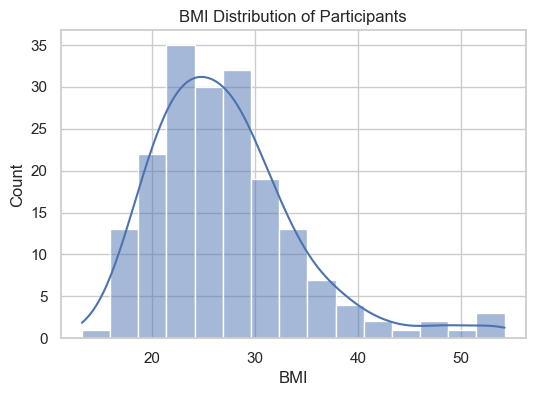

In [ ]:
#bmi distribution plot
plt.figure(figsize=(6,4))
sns.histplot(participants['BMI'], kde=True)
plt.title("BMI Distribution of Participants")
plt.show()


## data quality discussion
- **Completeness**: after imputation, only `symptoms_onset` remains incomplete (~20% missing).  
- **Accuracy**: extreme height values were adjusted to improve accuracy.  
- **Consistency**: units for height (cm) and weight (kg) were verified.  
- **Integrity**: `user_code` is unique, no duplicate participants

Overall, the dataset is fairly clean after minimal imputation and outlier handling.


## New data exploration - heart rate data



In [6]:
df = pd.read_csv("../data/heart_rate.csv")  

print("Shape:", df.shape)
df.info()



Shape: (523783, 4)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 523783 entries, 0 to 523782
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   user_code   523783 non-null  object
 1   datetime    523783 non-null  object
 2   heart_rate  523783 non-null  int64 
 3   is_resting  523783 non-null  int64 
dtypes: int64(2), object(2)
memory usage: 16.0+ MB


In [7]:
df.describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
user_code,523783,79,35c7355282,143879,NaN,NaN,NaN,NaN,NaN,NaN,NaN
datetime,523783,506422,2020-05-10 13:00:00,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
heart_rate,523783.0,NaN,NaN,NaN,90.856626,25.054152,10.0,71.0,87.0,108.0,232.0
is_resting,523783.0,NaN,NaN,NaN,0.005546,0.074266,0.0,0.0,0.0,0.0,1.0


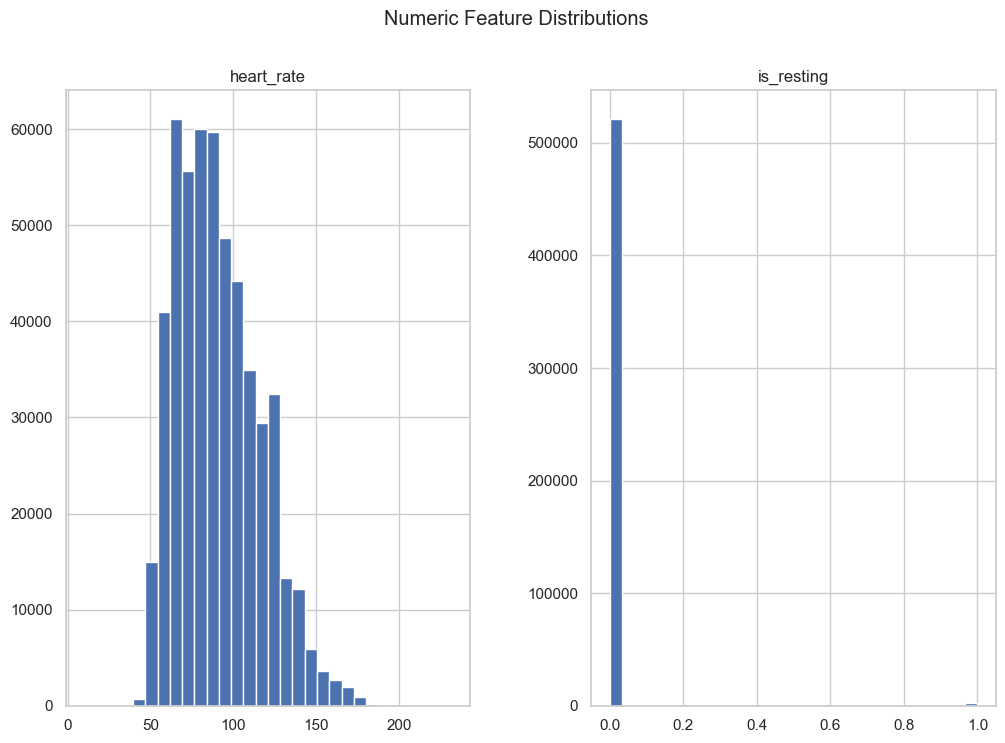

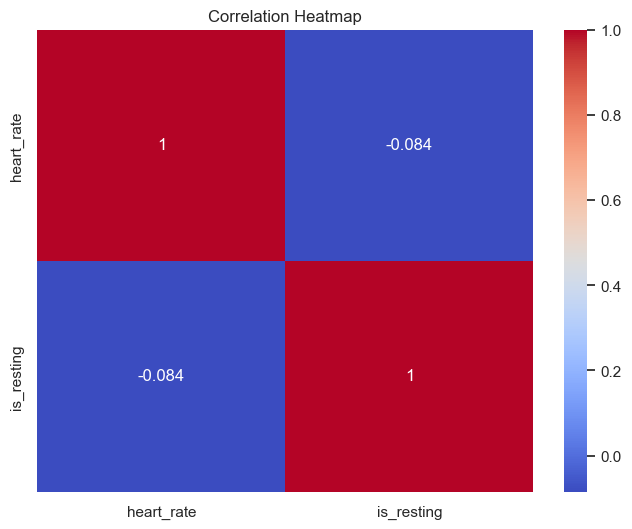

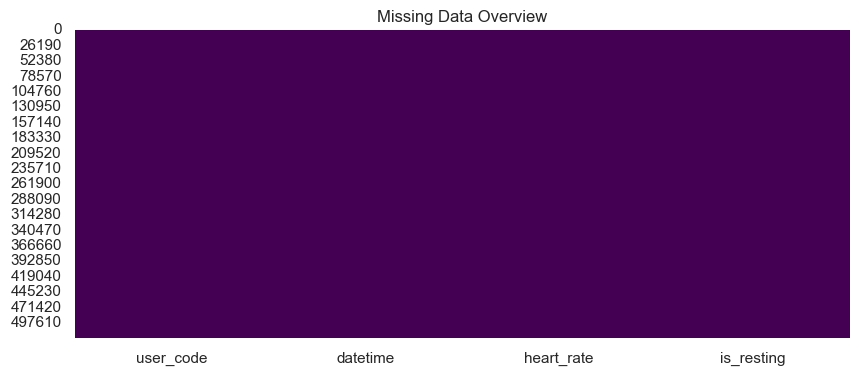

In [8]:
# histograms for all num columns
df.hist(figsize=(12, 8), bins=30)
plt.suptitle("Numeric Feature Distributions")
plt.show()

#heatmap (numeric only)
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

#missing values heatmap
plt.figure(figsize=(10,4))
sns.heatmap(df.isna(), cbar=False, cmap="viridis")
plt.title("Missing Data Overview")
plt.show()


# insights from the distribution plots
heart_rate: 
1) most values between 50–120 bpm
2) some outliers above 180–200 bpm (likely during exercise, stress, or measurement errors)
3) the distribution is roughly normal with a right tail

is_resting:
1) Highly imbalanced: mostly 0 (not resting), very few 1 (resting)
2) this imbalance could bias analysis, so it should be noted

missing values:
1) there are no missing values 

In [12]:
# Create rolling average column
heart_rate['hr_rolling_avg'] = (
    heart_rate['heart_rate']
    .rolling(window=10, min_periods=1)
    .mean()
)


In [ ]:

heart_rate.loc[heart_rate['heart_rate'] > 200, 'heart_rate'] = 200


unrealistic heart rates are capped so that the data is correct and no incorrect values in the data

In [11]:
heart_rate['is_high_hr'] = (heart_rate['heart_rate'] > 100).astype(int)

heart_rate[['user_code','datetime','heart_rate','hr_rolling_avg','is_resting','is_high_hr']].head()

,user_code,datetime,heart_rate,hr_rolling_avg,is_resting,is_high_hr
0,007b8190cf,2020-04-26 04:49:25,70,70.000000,0,0
1,01bad5a519,2020-04-23 06:21:03,74,72.000000,0,0
2,01bad5a519,2020-04-23 09:46:01,82,75.333333,0,0
3,01bad5a519,2020-04-23 14:05:06,90,79.000000,0,0
4,01bad5a519,2020-04-24 03:41:18,72,77.600000,0,0


flagging high heart rate (>100 bpm) as this information could be used tp redict other things like stress.

In [13]:
heart_rate['datetime'] = pd.to_datetime(heart_rate['datetime'])
heart_rate.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 523783 entries, 0 to 523782
Data columns (total 6 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   user_code       523783 non-null  object        
 1   datetime        523783 non-null  datetime64[ns]
 2   heart_rate      523783 non-null  int64         
 3   is_resting      523783 non-null  int64         
 4   is_high_hr      523783 non-null  int64         
 5   hr_rolling_avg  523783 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(3), object(1)
memory usage: 24.0+ MB


converted datetime to proper type

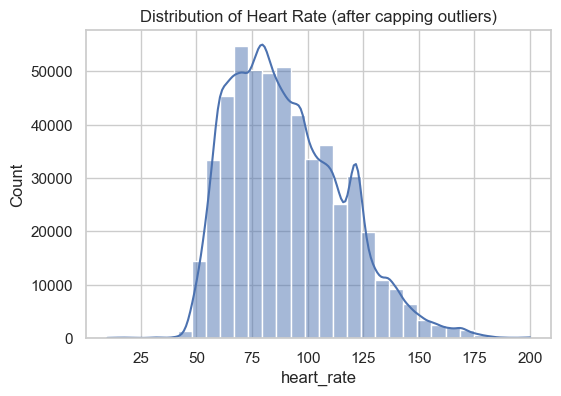

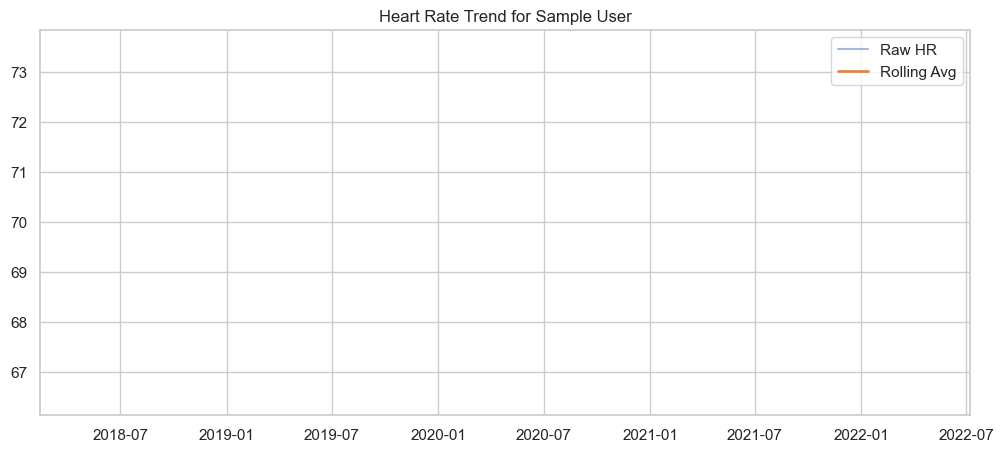

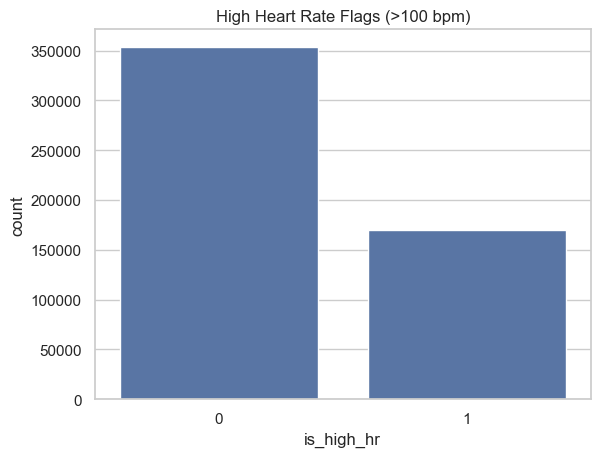

In [ ]:
#hr distribution after cleaning
plt.figure(figsize=(6,4))
sns.histplot(heart_rate['heart_rate'], kde=True, bins=30)
plt.title("Distribution of Heart Rate (after capping outliers)")
plt.show()

sample_user = heart_rate[heart_rate['user_code'] == heart_rate['user_code'].iloc[0]]
plt.figure(figsize=(12,5))
plt.plot(sample_user['datetime'], sample_user['heart_rate'], label='Raw HR', alpha=0.5)
plt.plot(sample_user['datetime'], sample_user['hr_rolling_avg'], label='Rolling Avg', linewidth=2)
plt.legend()
plt.title("Heart Rate Trend for Sample User")
plt.show()

# high hr coounts
sns.countplot(data=heart_rate, x='is_high_hr')
plt.title("High Heart Rate Flags (>100 bpm)")
plt.show()


# heart rate data insights
1) no missing values in this dataset.  
2) onverted `datetime` to proper type for time-series analysis.  
- outliers above 200 bpm were capped to ensure realistic heart rate values.  
- new features:
  - rolling average heart rate : smooths noise and helps identify trends
  - is_high_hr: flags readings above 100 bpm, useful for activity/stress detection 
- the `is_resting` column is highly imbalanced (most participants not resting)  
- distribution shows most heart rates between 60–100 bpm, consistent with healthy ranges 
